# Getting an overview of missing data in the home variables

In [1]:
!pip install pandas matplotlib
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

### Importing data and sorting out the home variables

In [3]:
Branddata = pd.read_csv("Branddata.csv")
df = Branddata.iloc[:, -12:]

### Creating Missingness Indicators

In [4]:
miss = df.isna().astype(int)

patterns = miss.astype(str).agg("".join, axis=1)

pattern_counts = patterns.value_counts().reset_index()
pattern_counts.columns = ["pattern", "count"]

In [5]:
matrix = pattern_counts["pattern"].apply(
    lambda x: [int(i) for i in x]
)

matrix = pd.DataFrame(
    matrix.tolist(),
    columns=df.columns
)

### Plots

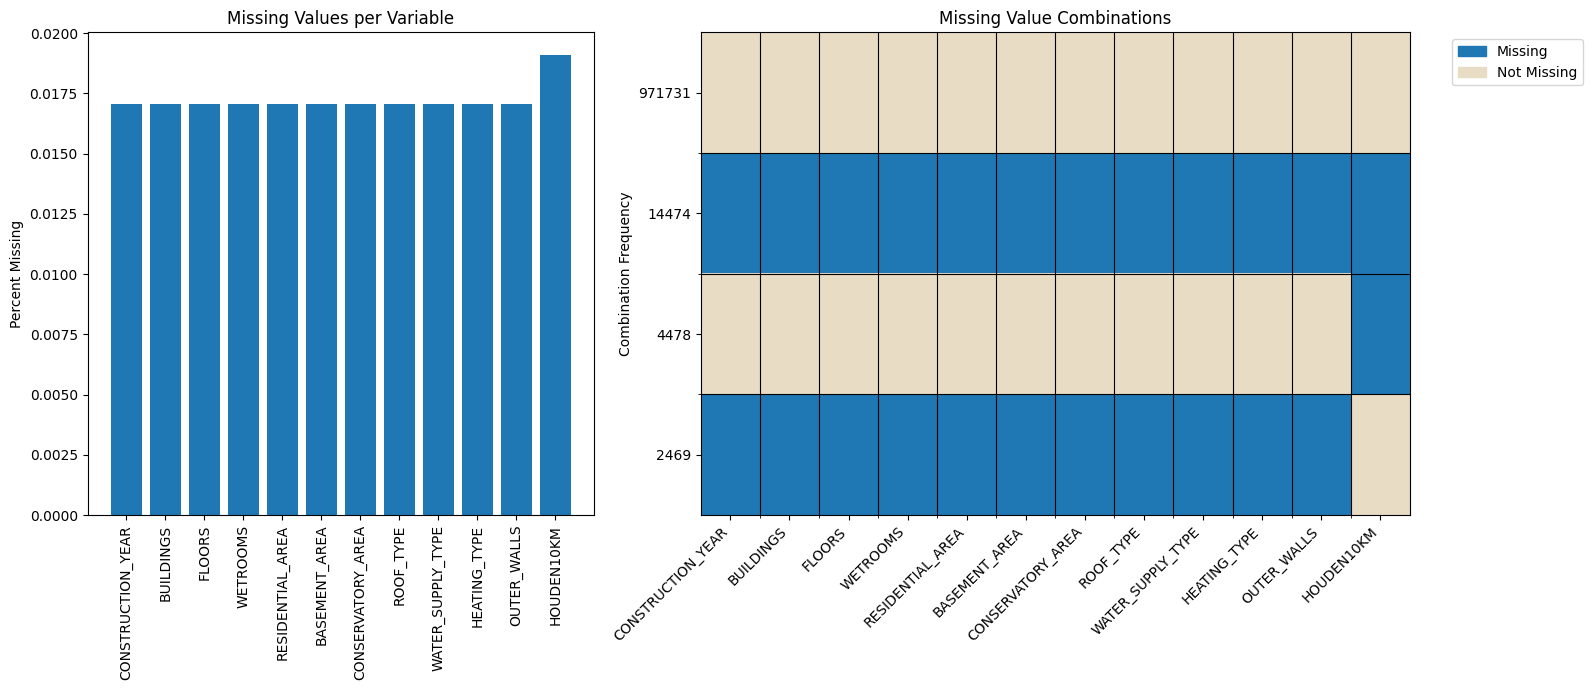

In [6]:
light_blue = 'tab:blue'
beige = "#E8DCC5"

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7),
    gridspec_kw={"width_ratios": [1, 1.4]}
)


### Plot 1: Missing percentage ###
missing_percent = miss.mean()

axes[0].bar(
    missing_percent.index,
    missing_percent.values,
    color=light_blue
)

axes[0].set_ylabel("Percent Missing")
axes[0].set_title("Missing Values per Variable")

axes[0].tick_params(
    axis="x",
    rotation=90
)


### Plot 2: Missing combinations ###
# 0 = Not Missing = beige
# 1 = Missing = blue
cmap = ListedColormap([beige, light_blue])

ax = axes[1]

ax.imshow(
    matrix,
    aspect="auto",
    cmap=cmap
)

ax.set_xticks(range(len(df.columns)))

ax.set_xticklabels(
    df.columns,
    rotation=45,
    ha="right"
)

ax.tick_params(
    top=False,
    bottom=True,
    labeltop=False,
    labelbottom=True
)

ax.set_yticks(range(len(pattern_counts)))

ax.set_yticklabels(
    pattern_counts["count"]
)


### Combining the plots ###
ax.set_ylabel("Combination Frequency")
ax.set_title("Missing Value Combinations")

ax.set_xticks(
    [x - 0.5 for x in range(1, len(df.columns))],
    minor=True
)

ax.set_yticks(
    [y - 0.5 for y in range(1, len(pattern_counts))],
    minor=True
)

ax.grid(
    which="minor",
    color="black",
    linewidth=0.8
)

not_missing = mpatches.Patch(
    color=beige,
    label="Not Missing"
)

missing_patch = mpatches.Patch(
    color=light_blue,
    label="Missing"
)

ax.legend(
    handles=[missing_patch, not_missing],
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()